#  03 Churn Classification — Model Training & Evaluation
This notebook trains and benchmarks multiple classifiers to predict customer churn:
- **SMOTE** for class imbalance handling
- **KNN, Decision Tree, Random Forest, XGBoost** benchmark
- Automatic best model selection by F1-Score
- Confusion matrix, ROC curve, and feature importance plots


##  Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import sys
import warnings

# Add project root to Python path for imports
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

from src.utils import (
    save_model, plot_confusion_matrix, plot_roc_curve,
    plot_feature_importance, calculate_metrics,
    get_resampling_strategy, compare_models
)

warnings.filterwarnings('ignore')
print("✅ Imports OK")

✅ Imports OK


##  Configuration

In [2]:
DATA_PATHS = {
    'X_train': '../data/train_test/X_train.csv',
    'X_test':  '../data/train_test/X_test.csv',
    'y_train': '../data/train_test/y_train.csv',
    'y_test':  '../data/train_test/y_test.csv',
}

RANDOM_STATE  = 42
REPORTS_DIR   = '../output'
MODELS_DIR    = '../models'
BEST_MODEL_PATH = f'{MODELS_DIR}/best_model_churn.pkl'

##  1. Load Data

In [3]:
for name, path in DATA_PATHS.items():
    assert os.path.exists(path), f"❌ Missing file: {path} — run preprocessing_pipeline.ipynb first."

X_train = pd.read_csv(DATA_PATHS['X_train'])
X_test  = pd.read_csv(DATA_PATHS['X_test'])
y_train = pd.read_csv(DATA_PATHS['y_train']).values.ravel()
y_test  = pd.read_csv(DATA_PATHS['y_test']).values.ravel()

print(f"✅ Data loaded successfully")
print(f"   Train: {X_train.shape} | Test: {X_test.shape}")
print(f"   Churn rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

✅ Data loaded successfully
   Train: (3287, 10) | Test: (822, 10)
   Churn rate — Train: 34.38% | Test: 34.43%


##  2. Class Imbalance — SMOTE Oversampling

In [4]:
print(f"Before SMOTE — Class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")

sm = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = sm.fit_resample(X_train, y_train)

print(f"After  SMOTE — Class distribution: {dict(zip(*np.unique(y_res, return_counts=True)))}")
print(f"✅ Resampled dataset shape: {X_res.shape}")

Before SMOTE — Class distribution: {np.int64(0): np.int64(2157), np.int64(1): np.int64(1130)}
After  SMOTE — Class distribution: {np.int64(0): np.int64(2157), np.int64(1): np.int64(2157)}
✅ Resampled dataset shape: (4314, 10)


##  3. Define Classifiers

In [5]:
classifiers = {
    'KNN': KNeighborsClassifier(
        n_neighbors=5
    ),
    'DecisionTree': DecisionTreeClassifier(
        criterion='entropy',
        random_state=RANDOM_STATE
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
    'XGBoost': xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ),
}

os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

print(f"✅ {len(classifiers)} classifiers defined: {list(classifiers.keys())}")

✅ 4 classifiers defined: ['KNN', 'DecisionTree', 'RandomForest', 'XGBoost']


##  4. Training & Evaluation Loop


────────────────────────────────────────
  Training: KNN
────────────────────────────────────────

MÉTRIQUES
Accuracy    : 0.8820
Precision   : 0.8163
Recall      : 0.8481
F1-Score    : 0.8319
ROC-AUC     : 0.9213
  Accuracy  : 0.8820
  F1-Score  : 0.8319
  ROC-AUC   : 0.9213


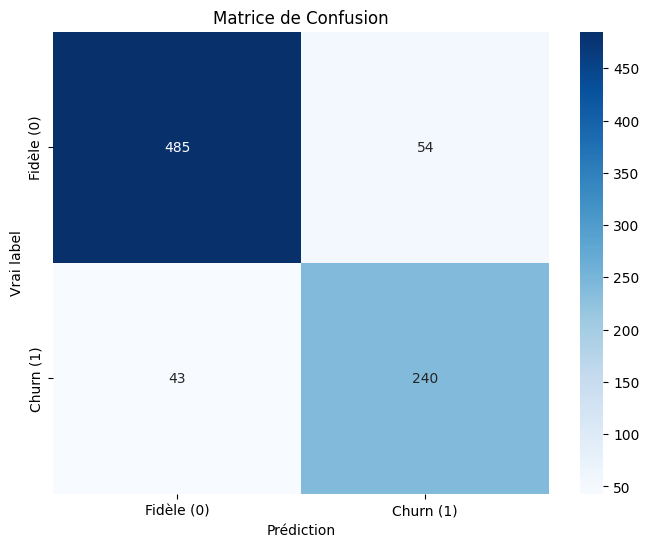

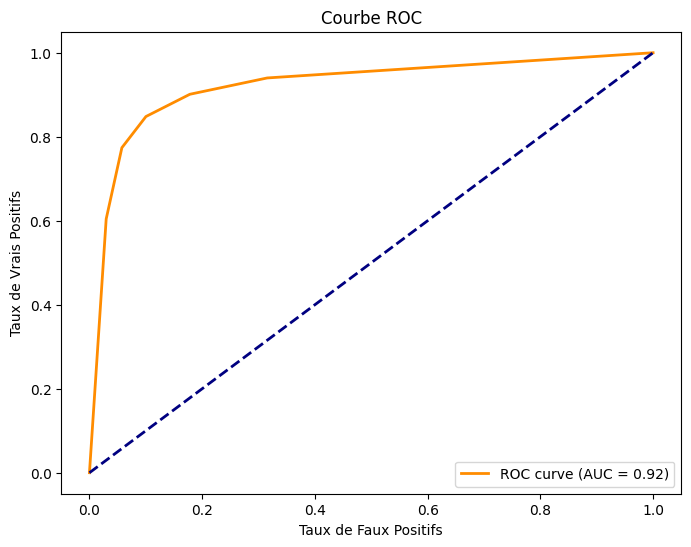


────────────────────────────────────────
  Training: DecisionTree
────────────────────────────────────────

MÉTRIQUES
Accuracy    : 0.8297
Precision   : 0.7329
Recall      : 0.7951
F1-Score    : 0.7627
ROC-AUC     : 0.8215
  Accuracy  : 0.8297
  F1-Score  : 0.7627
  ROC-AUC   : 0.8215


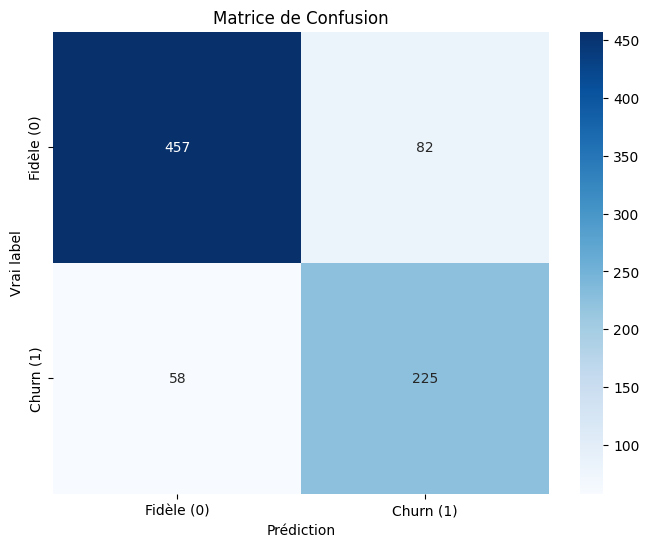

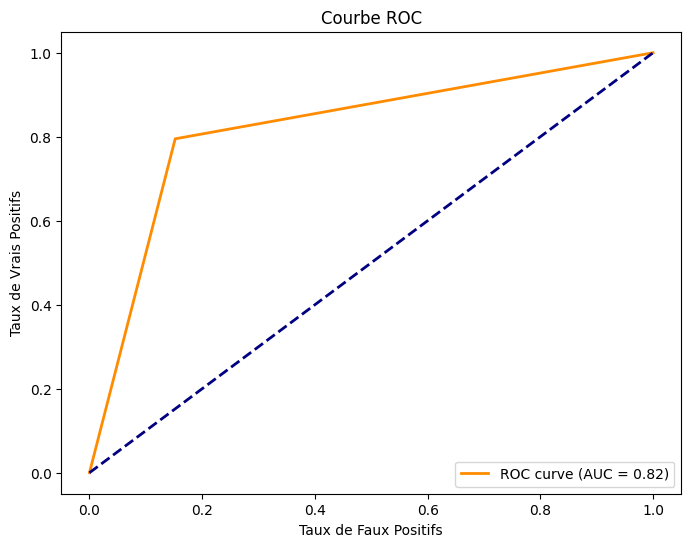


────────────────────────────────────────
  Training: RandomForest
────────────────────────────────────────

MÉTRIQUES
Accuracy    : 0.8893
Precision   : 0.8529
Recall      : 0.8198
F1-Score    : 0.8360
ROC-AUC     : 0.9415
  Accuracy  : 0.8893
  F1-Score  : 0.8360
  ROC-AUC   : 0.9415


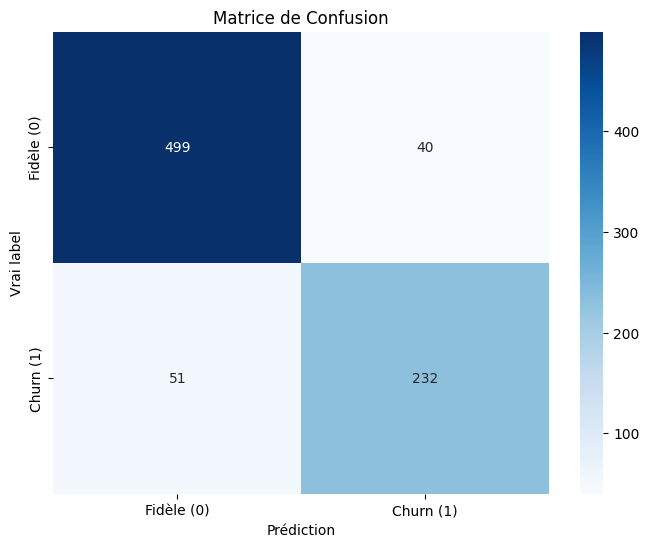

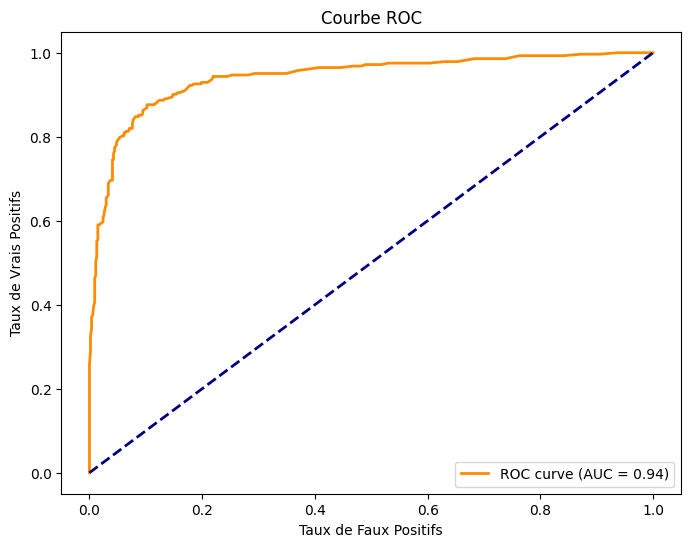


────────────────────────────────────────
  Training: XGBoost
────────────────────────────────────────

MÉTRIQUES
Accuracy    : 0.8881
Precision   : 0.8351
Recall      : 0.8410
F1-Score    : 0.8380
ROC-AUC     : 0.9449
  Accuracy  : 0.8881
  F1-Score  : 0.8380
  ROC-AUC   : 0.9449


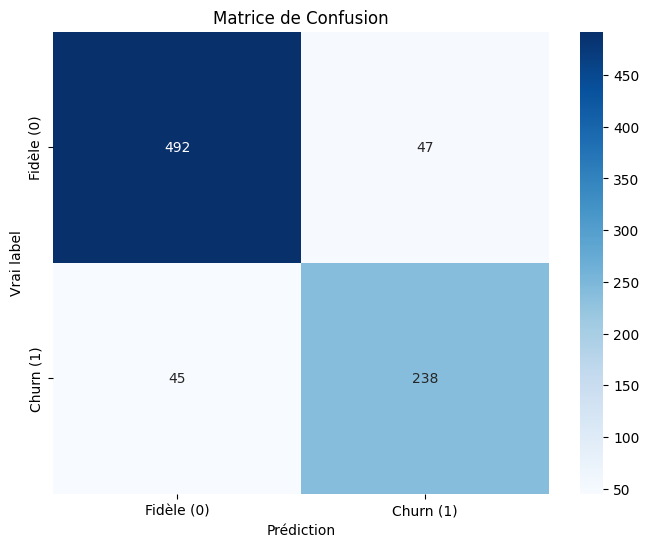

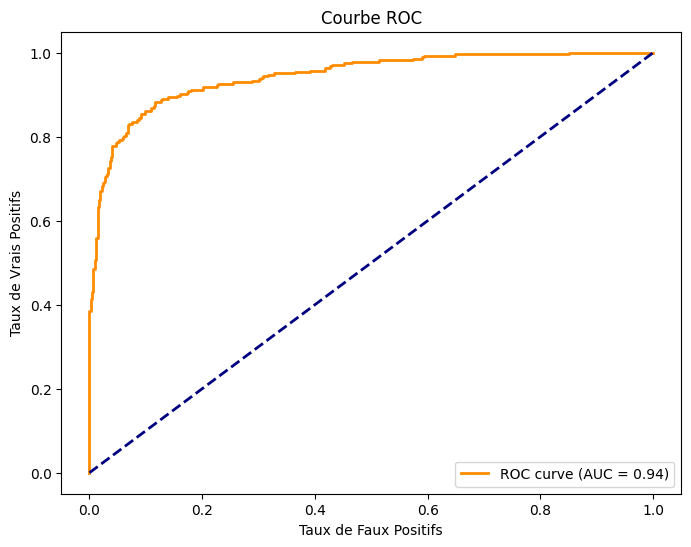


✅ All classifiers trained and evaluated.


In [6]:
results = {}

for name, clf in classifiers.items():
    print(f"\n{'─'*40}")
    print(f"  Training: {name}")
    print(f"{'─'*40}")

    # Train
    clf.fit(X_res, y_res)

    # Predict
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = calculate_metrics(y_test, y_pred, y_proba)
    results[name] = metrics

    print(f"  Accuracy  : {metrics.get('Accuracy', 'N/A'):.4f}")
    print(f"  F1-Score  : {metrics.get('F1-Score', 'N/A'):.4f}")
    print(f"  ROC-AUC   : {metrics.get('ROC-AUC',  'N/A'):.4f}")

    # Plots
    plot_confusion_matrix(y_test, y_pred,  save_path=f'{REPORTS_DIR}/cm_{name}.png')
    plot_roc_curve(y_test, y_proba,         save_path=f'{REPORTS_DIR}/roc_{name}.png')

print("\n✅ All classifiers trained and evaluated.")

##  5. Model Comparison

In [7]:
compare_models(results)


COMPARAISON FINALE DES MODÈLES:
          Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0           KNN    0.8820     0.8163  0.8481    0.8319   0.9213
1  DecisionTree    0.8297     0.7329  0.7951    0.7627   0.8215
2  RandomForest    0.8893     0.8529  0.8198    0.8360   0.9415
3       XGBoost    0.8881     0.8351  0.8410    0.8380   0.9449


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,KNN,0.881995,0.816327,0.848057,0.831889,0.921311
1,DecisionTree,0.829684,0.732899,0.795053,0.762712,0.821460
2,RandomForest,0.889294,0.852941,0.819788,0.836036,0.941450
3,XGBoost,0.888078,0.835088,0.840989,0.838028,0.944931


In [8]:
# Display results as a sorted DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1-Score', ascending=False)
results_df.style.highlight_max(axis=0, color='lightgreen')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost,0.888078,0.835088,0.840989,0.838028,0.944931
RandomForest,0.889294,0.852941,0.819788,0.836036,0.941450
KNN,0.881995,0.816327,0.848057,0.831889,0.921311
DecisionTree,0.829684,0.732899,0.795053,0.762712,0.821460


##  6. Select & Save Best Model

In [9]:
best_model_name = max(results, key=lambda x: results[x]['F1-Score'])
best_model      = classifiers[best_model_name]
best_metrics    = results[best_model_name]

print(f" Best model: {best_model_name}")
print(f"   F1-Score : {best_metrics['F1-Score']:.4f}")
print(f"   ROC-AUC  : {best_metrics.get('ROC-AUC', 'N/A'):.4f}")

 Best model: XGBoost
   F1-Score : 0.8380
   ROC-AUC  : 0.9449


In [10]:
save_model(best_model, BEST_MODEL_PATH)
print(f"✅ Best model saved to: {BEST_MODEL_PATH}")

 Modèle sauvegardé: ../models/best_model_churn.pkl
✅ Best model saved to: ../models/best_model_churn.pkl


## ✅ Summary

In [11]:
print("=" * 50)
print("    CLASSIFICATION TRAINING — COMPLETE")
print("=" * 50)
print(f"  Best classifier : {best_model_name}")
print(f"  F1-Score        : {best_metrics['F1-Score']:.4f}")
print(f"  ROC-AUC         : {best_metrics.get('ROC-AUC', 'N/A'):.4f}")
print("")
print("  Saved artifacts:")
print(f"    {BEST_MODEL_PATH}")
for name in classifiers:
    print(f"    {REPORTS_DIR}/cm_{name}.png")
    print(f"    {REPORTS_DIR}/roc_{name}.png")
print("=" * 50)

    CLASSIFICATION TRAINING — COMPLETE
  Best classifier : XGBoost
  F1-Score        : 0.8380
  ROC-AUC         : 0.9449

  Saved artifacts:
    ../models/best_model_churn.pkl
    ../output/cm_KNN.png
    ../output/roc_KNN.png
    ../output/cm_DecisionTree.png
    ../output/roc_DecisionTree.png
    ../output/cm_RandomForest.png
    ../output/roc_RandomForest.png
    ../output/cm_XGBoost.png
    ../output/roc_XGBoost.png
